# EPLB Redundancy Tuning

Simulate different `num_redundant_experts` values using dumped expert load
data to find the minimal redundancy that achieves good load balance.

## How it works

The EPLB rebalancing algorithm (`DefaultEplbPolicy.rebalance_experts_hierarchical`)
is a pure-numpy, stateless function. Given logical expert loads and a target
`num_physical_experts`, it produces an optimal physical-to-logical mapping.

This notebook:
1. Loads expert load dumps (produced by `EPLBConfig.expert_load_dump_dir`)
2. Recovers **logical** expert loads from the dumped physical loads + mapping
3. Replays them through the algorithm with varying `num_redundant_experts`
4. Plots predicted balancedness vs. experts-per-rank to find the sweet spot

### Caveats

- The simulation assumes tokens for a logical expert split evenly across its
  replicas. In practice the split depends on the dispatch method (DeepEP, naive
  all-to-all). Results represent the **theoretical best-case** balancedness for
  each redundancy level.
- To avoid optimistic bias from evaluating on the same load used to choose the
  mapping, the sweep supports a **train/eval split**: one snapshot drives the
  rebalancing algorithm, a different snapshot measures the resulting
  balancedness. The multi-snapshot mode uses leave-one-out by default.

In [35]:
import json
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

# ---------------------------------------------------------------------------
# Data loading (same schema as eplb_expert_load_analysis.ipynb)
# ---------------------------------------------------------------------------


@dataclass
class EplbLoadData:
    """Parsed expert load dump with derived fields."""

    model: str
    dataset: str
    tag: str
    world_size: int
    num_layers: int
    num_physical: int
    num_logical: int
    num_redundant: int
    num_groups: int
    experts_per_rank: int
    window_size: int
    data: dict
    subtitle: str
    load_key: str

    def snapshot(self, idx: int = -1):
        snap = self.data["snapshots"][idx]
        return (
            snap,
            np.array(snap[self.load_key]),
            np.array(snap["physical_to_logical_map"]),
        )


def load_eplb_data(
    dataset: str,
    model: str,
    dump_root: str = "../explore_eplb_results",
    world_size: int | None = None,
    tag: str = "",
    num_groups: int = 1,
) -> EplbLoadData:
    """Load a JSON dump and return an EplbLoadData."""
    model_name = model.replace("/", "_")
    subdir = f"{tag}/" if tag else ""
    dump_file = Path(f"{dump_root}/{dataset}/{subdir}{model_name}_expert_load.json")
    with open(dump_file) as f:
        data = json.load(f)

    for k in [
        "model_name",
        "world_size",
        "num_moe_layers",
        "num_physical_experts",
        "num_logical_experts",
        "num_redundant_experts",
        "window_size",
    ]:
        print(f"{k}: {data[k]}")
    print(f"snapshots: {len(data['snapshots'])}")

    ws = world_size if world_size is not None else data["world_size"]
    num_physical = data["num_physical_experts"]
    assert num_physical % ws == 0

    subtitle = (
        f"{model}  |  dataset: {dataset}  |  EP={ws}  |  window={data['window_size']}"
    )
    if tag:
        subtitle += f"  |  {tag}"

    return EplbLoadData(
        model=model,
        dataset=dataset,
        tag=tag,
        world_size=ws,
        num_layers=data["num_moe_layers"],
        num_physical=num_physical,
        num_logical=data["num_logical_experts"],
        num_redundant=data["num_redundant_experts"],
        num_groups=num_groups,
        experts_per_rank=num_physical // ws,
        window_size=data["window_size"],
        data=data,
        subtitle=subtitle,
        load_key="window_expert_load",
    )

In [36]:
# ---------------------------------------------------------------------------
# EPLB rebalancing algorithm (pure numpy, no torch dependency).
# Extracted from vllm/distributed/eplb/policy/default.py to avoid pulling in
# the full vLLM import chain which requires torch/CUDA.
# ---------------------------------------------------------------------------


def balanced_packing(
    weight: np.ndarray, num_packs: int
) -> tuple[np.ndarray, np.ndarray]:
    """Pack n weighted objects into m packs, minimizing max pack weight."""
    num_layers, num_groups = weight.shape
    assert num_groups % num_packs == 0
    groups_per_pack = num_groups // num_packs

    if groups_per_pack == 1:
        pack_index = np.tile(np.arange(num_groups, dtype=np.int64), (num_layers, 1))
        rank_in_pack = np.zeros_like(pack_index, dtype=np.int64)
        return pack_index, rank_in_pack

    indices = np.argsort(-weight, axis=-1)
    pack_index = np.full((num_layers, num_groups), -1, dtype=np.int64)
    rank_in_pack = np.full((num_layers, num_groups), -1, dtype=np.int64)
    pack_weights = np.zeros((num_layers, num_packs), dtype=np.float64)
    pack_items = np.zeros((num_layers, num_packs), dtype=np.int64)

    for layer_idx in range(num_layers):
        weights_row = pack_weights[layer_idx]
        items_row = pack_items[layer_idx]
        for group in indices[layer_idx]:
            pack = int(np.argmin(weights_row))
            pack_index[layer_idx, group] = pack
            rank_in_pack[layer_idx, group] = items_row[pack]
            weights_row[pack] += weight[layer_idx, group]
            items_row[pack] += 1
            if items_row[pack] == groups_per_pack:
                weights_row[pack] = np.inf

    return pack_index, rank_in_pack


def replicate_experts(
    weight: np.ndarray, num_phy: int
) -> tuple[np.ndarray, np.ndarray]:
    """Greedy replication: give extra slots to the highest-load-per-replica expert."""
    n, num_log = weight.shape
    assert num_phy >= num_log
    phy2log = np.tile(np.arange(num_phy, dtype=np.int64), (n, 1))
    logcnt = np.ones((n, num_log), dtype=np.int64)
    arangen = np.arange(n, dtype=np.int64)
    for i in range(num_log, num_phy):
        redundant_indices = np.argmax(weight / logcnt, axis=-1)
        phy2log[:, i] = redundant_indices
        logcnt[arangen, redundant_indices] += 1
    return phy2log, logcnt


def rebalance_experts_hierarchical(
    weight: np.ndarray,
    num_physical_experts: int,
    num_groups: int,
    num_nodes: int,
    num_gpus: int,
) -> np.ndarray:
    """Hierarchical expert rebalancing: groups->nodes, replicate, pack->GPUs."""
    num_layers, num_logical_experts = weight.shape
    assert num_logical_experts % num_groups == 0
    group_size = num_logical_experts // num_groups
    assert num_groups % num_nodes == 0
    groups_per_node = num_groups // num_nodes
    assert num_gpus % num_nodes == 0
    assert num_physical_experts % num_gpus == 0
    phy_experts_per_gpu = num_physical_experts // num_gpus

    def inverse(perm: np.ndarray) -> np.ndarray:
        inv = np.empty_like(perm)
        row_idx = np.arange(perm.shape[0])[:, None]
        col_idx = np.arange(perm.shape[1], dtype=np.int64)
        inv[row_idx, perm] = col_idx
        return inv

    tokens_per_group = weight.reshape(num_layers, num_groups, group_size).sum(axis=-1)
    group_pack_index, group_rank_in_pack = balanced_packing(tokens_per_group, num_nodes)
    log2mlog = (
        (
            (group_pack_index * groups_per_node + group_rank_in_pack)[..., None]
            * group_size
        )
        + np.arange(group_size, dtype=np.int64)
    ).reshape(num_layers, num_logical_experts)
    mlog2log = inverse(log2mlog)

    tokens_per_mlog = np.take_along_axis(weight, mlog2log, axis=1).reshape(
        -1, num_logical_experts // num_nodes
    )
    phy2mlog, mlogcnt = replicate_experts(
        tokens_per_mlog, num_physical_experts // num_nodes
    )

    tokens_per_phy = np.take_along_axis(tokens_per_mlog / mlogcnt, phy2mlog, axis=1)
    pack_index, rank_in_pack = balanced_packing(tokens_per_phy, num_gpus // num_nodes)
    phy2pphy = pack_index * phy_experts_per_gpu + rank_in_pack
    pphy2phy = inverse(phy2pphy)

    pphy2mlog = np.take_along_axis(phy2mlog, pphy2phy, axis=1)
    pphy2mlog = (
        pphy2mlog.reshape(num_layers, num_nodes, -1)
        + np.arange(
            0,
            num_logical_experts,
            num_logical_experts // num_nodes,
            dtype=np.int64,
        )[None, :, None]
    ).reshape(num_layers, -1)
    pphy2log = np.take_along_axis(mlog2log, pphy2mlog, axis=1)
    return pphy2log


def _rebalance_single_layer(
    weight_1l: np.ndarray,
    num_physical_experts: int,
    num_groups: int,
    num_nodes: int,
    num_gpus: int,
) -> np.ndarray:
    """Run the hierarchical algorithm on a single layer.

    Args:
        weight_1l: [num_logical_experts] — 1-D load for one layer
    Returns:
        phy2log: [num_physical_experts] — 1-D mapping for that layer
    """
    return rebalance_experts_hierarchical(
        weight_1l[np.newaxis, :],
        num_physical_experts,
        num_groups,
        num_nodes,
        num_gpus,
    )[0]


def rebalance_experts_per_layer(
    weight: np.ndarray,
    num_physical_per_layer: np.ndarray,
    num_groups: int,
    num_nodes: int,
    num_gpus: int,
) -> list[np.ndarray]:
    """Rebalance with a different number of physical experts per layer.

    Args:
        weight: [num_layers, num_logical_experts]
        num_physical_per_layer: [num_layers] — per-layer physical expert count,
            each must be divisible by num_gpus and >= num_logical_experts
    Returns:
        list of 1-D arrays, phy2log[layer] has length num_physical_per_layer[layer]
    """
    num_layers = weight.shape[0]
    assert len(num_physical_per_layer) == num_layers

    unique_counts = np.unique(num_physical_per_layer)
    results: list[np.ndarray | None] = [None] * num_layers

    for nphy in unique_counts:
        layer_mask = num_physical_per_layer == nphy
        layer_indices = np.where(layer_mask)[0]
        batch_weight = weight[layer_indices]
        batch_phy2log = rebalance_experts_hierarchical(
            batch_weight,
            int(nphy),
            num_groups,
            num_nodes,
            num_gpus,
        )
        for j, li in enumerate(layer_indices):
            results[li] = batch_phy2log[j]

    return results  # type: ignore[return-value]

In [37]:
# ---------------------------------------------------------------------------
# Core simulation
# ---------------------------------------------------------------------------


def recover_logical_load(
    physical_load: np.ndarray,
    physical_to_logical: np.ndarray,
    num_logical: int,
) -> np.ndarray:
    """Reconstruct per-logical-expert load from physical load + mapping.

    This reverses the scatter that happens during inference: tokens routed
    to physical experts are summed back onto their logical expert.

    Args:
        physical_load: [num_layers, num_physical]
        physical_to_logical: [num_layers, num_physical]
        num_logical: number of logical experts

    Returns:
        logical_load: [num_layers, num_logical]
    """
    num_layers = physical_load.shape[0]
    logical_load = np.zeros((num_layers, num_logical), dtype=np.float64)
    rows = np.arange(num_layers)[:, None]
    np.add.at(logical_load, (rows, physical_to_logical), physical_load)
    return logical_load


def compute_balancedness(
    phy2log: np.ndarray,
    logical_load: np.ndarray,
    num_gpus: int,
) -> np.ndarray:
    """Compute per-layer balancedness for a given physical-to-logical mapping.

    Assumes each logical expert's load is split evenly across its replicas.

    Args:
        phy2log: [num_layers, num_physical] — rectangular (uniform redundancy)
        logical_load: [num_layers, num_logical]

    Returns:
        balancedness: [num_layers], mean_rank_load / max_rank_load per layer
    """
    num_layers, num_physical = phy2log.shape
    experts_per_rank = num_physical // num_gpus

    replica_count = np.zeros_like(logical_load)
    rows = np.arange(num_layers)[:, None]
    np.add.at(replica_count, (rows, phy2log), 1)

    per_replica_load = np.where(replica_count > 0, logical_load / replica_count, 0.0)
    phy_load = per_replica_load[rows, phy2log]

    rank_load = phy_load.reshape(num_layers, num_gpus, experts_per_rank).sum(axis=2)
    mean_load = rank_load.mean(axis=1)
    max_load = rank_load.max(axis=1)
    return np.where(max_load > 0, mean_load / max_load, 0.0)


def compute_balancedness_one_layer(
    phy2log_1l: np.ndarray,
    logical_load_1l: np.ndarray,
    num_gpus: int,
) -> float:
    """Balancedness for a single layer (variable-width phy2log)."""
    num_physical = phy2log_1l.shape[0]
    num_logical = logical_load_1l.shape[0]
    experts_per_rank = num_physical // num_gpus

    replica_count = np.zeros(num_logical, dtype=np.float64)
    np.add.at(replica_count, phy2log_1l, 1)

    per_replica = np.where(replica_count > 0, logical_load_1l / replica_count, 0.0)
    phy_load = per_replica[phy2log_1l]

    rank_load = phy_load.reshape(num_gpus, experts_per_rank).sum(axis=1)
    mean_load = rank_load.mean()
    max_load = rank_load.max()
    return float(mean_load / max_load) if max_load > 0 else 0.0


@dataclass
class SweepResult:
    """Results of sweeping num_redundant_experts."""

    num_redundant_values: np.ndarray
    num_physical_values: np.ndarray
    experts_per_rank: np.ndarray
    mean_balancedness: np.ndarray
    worst_balancedness: np.ndarray
    p5_balancedness: np.ndarray


def simulate_redundancy_sweep(
    d: EplbLoadData,
    train_snapshot_idx: int = -1,
    eval_snapshot_idx: int | None = None,
    max_redundant: int | None = None,
    num_nodes: int = 1,
) -> SweepResult:
    """Sweep num_redundant_experts and compute predicted balancedness.

    The algorithm is fitted on ``train_snapshot_idx`` and evaluated on
    ``eval_snapshot_idx``.  When they differ, this avoids the optimistic
    bias of evaluating on the same data used to choose the mapping.

    Args:
        d: loaded EPLB dump data
        train_snapshot_idx: snapshot whose load drives the rebalance algorithm
        eval_snapshot_idx: snapshot whose load is used to measure balancedness
            (default: same as train_snapshot_idx)
        max_redundant: upper bound for sweep (default: num_logical)
        num_nodes: number of server nodes for hierarchical packing
    """
    _, train_phys_load, train_p2l = d.snapshot(train_snapshot_idx)
    train_logical = recover_logical_load(train_phys_load, train_p2l, d.num_logical)

    if eval_snapshot_idx is not None:
        _, eval_phys_load, eval_p2l = d.snapshot(eval_snapshot_idx)
        eval_logical = recover_logical_load(eval_phys_load, eval_p2l, d.num_logical)
    else:
        eval_logical = train_logical

    num_gpus = d.world_size
    num_groups = d.num_groups

    if max_redundant is None:
        max_redundant = d.num_logical

    candidates = []
    for nr in range(0, max_redundant + 1):
        num_phy = d.num_logical + nr
        if num_phy % num_gpus != 0:
            continue
        candidates.append(nr)

    num_redundant_values = np.array(candidates)
    num_physical_values = d.num_logical + num_redundant_values
    epr = num_physical_values // num_gpus
    mean_bal = np.zeros(len(candidates))
    worst_bal = np.zeros(len(candidates))
    p5_bal = np.zeros(len(candidates))

    effective_groups = num_groups if (num_groups % num_nodes == 0) else 1
    effective_nodes = num_nodes if (num_groups % num_nodes == 0) else 1

    for i, nr in enumerate(candidates):
        num_phy = d.num_logical + nr
        phy2log = rebalance_experts_hierarchical(
            train_logical, num_phy, effective_groups, effective_nodes, num_gpus
        )
        bal = compute_balancedness(phy2log, eval_logical, num_gpus)
        mean_bal[i] = bal.mean()
        worst_bal[i] = bal.min()
        p5_bal[i] = np.percentile(bal, 5)

    return SweepResult(
        num_redundant_values=num_redundant_values,
        num_physical_values=num_physical_values,
        experts_per_rank=epr,
        mean_balancedness=mean_bal,
        worst_balancedness=worst_bal,
        p5_balancedness=p5_bal,
    )


# ---------------------------------------------------------------------------
# Per-layer redundancy allocation
# ---------------------------------------------------------------------------


def allocate_redundancy_per_layer(
    logical_load: np.ndarray,
    total_redundant: int,
    num_gpus: int,
    num_groups: int,
    num_nodes: int,
) -> np.ndarray:
    """Greedily allocate a total redundancy budget across layers.

    At each step, gives the next chunk of redundant experts (size = num_gpus,
    the minimum increment that keeps num_physical divisible by num_gpus) to
    the layer whose worst-layer balancedness benefits most.

    Args:
        logical_load: [num_layers, num_logical] — load to optimise for
        total_redundant: total redundant expert slots to distribute
        num_gpus: EP world size
        num_groups: expert groups for hierarchical algorithm
        num_nodes: server nodes

    Returns:
        num_redundant_per_layer: [num_layers] — allocated redundant experts
    """
    num_layers, num_logical = logical_load.shape
    step = num_gpus
    num_steps = total_redundant // step
    effective_groups = num_groups if (num_groups % num_nodes == 0) else 1
    effective_nodes = num_nodes if (num_groups % num_nodes == 0) else 1

    alloc = np.zeros(num_layers, dtype=np.int64)

    current_bal = np.empty(num_layers)
    for l in range(num_layers):
        nphy = num_logical + alloc[l]
        p2l = _rebalance_single_layer(
            logical_load[l], nphy, effective_groups, effective_nodes, num_gpus
        )
        current_bal[l] = compute_balancedness_one_layer(p2l, logical_load[l], num_gpus)

    for _ in range(num_steps):
        worst_layer = int(np.argmin(current_bal))
        nphy_new = num_logical + alloc[worst_layer] + step
        p2l_new = _rebalance_single_layer(
            logical_load[worst_layer],
            nphy_new,
            effective_groups,
            effective_nodes,
            num_gpus,
        )
        new_bal = compute_balancedness_one_layer(
            p2l_new,
            logical_load[worst_layer],
            num_gpus,
        )
        alloc[worst_layer] += step
        current_bal[worst_layer] = new_bal

    return alloc


@dataclass
class PerLayerSweepResult:
    """Results of sweeping total redundancy with per-layer allocation."""

    total_redundant_values: np.ndarray
    mean_epr: np.ndarray
    mean_balancedness: np.ndarray
    worst_balancedness: np.ndarray
    p5_balancedness: np.ndarray
    alloc_at_each_budget: list[np.ndarray]


def simulate_per_layer_sweep(
    d: EplbLoadData,
    train_snapshot_idx: int = -1,
    eval_snapshot_idx: int | None = None,
    max_total_redundant: int | None = None,
    num_nodes: int = 1,
) -> PerLayerSweepResult:
    """Sweep total redundancy budget with per-layer allocation.

    For each total budget, greedily allocates redundant experts to layers
    that need them most, then evaluates on the eval snapshot.
    """
    _, train_phys_load, train_p2l = d.snapshot(train_snapshot_idx)
    train_logical = recover_logical_load(train_phys_load, train_p2l, d.num_logical)

    if eval_snapshot_idx is not None:
        _, eval_phys_load, eval_p2l = d.snapshot(eval_snapshot_idx)
        eval_logical = recover_logical_load(eval_phys_load, eval_p2l, d.num_logical)
    else:
        eval_logical = train_logical

    num_gpus = d.world_size
    num_groups = d.num_groups
    effective_groups = num_groups if (num_groups % num_nodes == 0) else 1
    effective_nodes = num_nodes if (num_groups % num_nodes == 0) else 1

    if max_total_redundant is None:
        max_total_redundant = d.num_logical * d.num_layers

    step = num_gpus
    candidates = list(range(0, max_total_redundant + 1, step))

    total_vals = np.array(candidates)
    mean_epr = np.zeros(len(candidates))
    mean_bal = np.zeros(len(candidates))
    worst_bal = np.zeros(len(candidates))
    p5_bal = np.zeros(len(candidates))
    allocs = []

    for ci, total_nr in enumerate(candidates):
        alloc = allocate_redundancy_per_layer(
            train_logical,
            total_nr,
            num_gpus,
            num_groups,
            num_nodes,
        )
        allocs.append(alloc.copy())

        num_phy_per_layer = d.num_logical + alloc
        phy2log_list = rebalance_experts_per_layer(
            eval_logical,
            num_phy_per_layer,
            effective_groups,
            effective_nodes,
            num_gpus,
        )
        bal = np.array(
            [
                compute_balancedness_one_layer(p2l, eval_logical[l], num_gpus)
                for l, p2l in enumerate(phy2log_list)
            ]
        )
        mean_bal[ci] = bal.mean()
        worst_bal[ci] = bal.min()
        p5_bal[ci] = np.percentile(bal, 5)
        mean_epr[ci] = num_phy_per_layer.mean() / num_gpus

    return PerLayerSweepResult(
        total_redundant_values=total_vals,
        mean_epr=mean_epr,
        mean_balancedness=mean_bal,
        worst_balancedness=worst_bal,
        p5_balancedness=p5_bal,
        alloc_at_each_budget=allocs,
    )

In [38]:
# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------


def plot_redundancy_sweep(
    result: SweepResult,
    title: str = "",
    target_balancedness: float | None = 0.90,
    current_redundant: int | None = None,
):
    """Plot balancedness vs. experts-per-rank for a redundancy sweep.

    The target line and annotation are based on worst-layer balancedness,
    since the slowest layer determines end-to-end latency.
    """
    fig, ax1 = plt.subplots(figsize=(12, 5))

    nr = result.num_redundant_values
    ax1.plot(
        nr,
        result.worst_balancedness,
        "s-",
        markersize=5,
        label="Worst-layer balancedness",
        color="coral",
        zorder=3,
    )
    ax1.plot(
        nr,
        result.p5_balancedness,
        "^-",
        markersize=4,
        label="5th-percentile balancedness",
        color="mediumpurple",
        alpha=0.7,
    )
    ax1.plot(
        nr,
        result.mean_balancedness,
        "o-",
        markersize=3,
        label="Mean balancedness",
        color="steelblue",
        alpha=0.5,
    )

    ax1.set_xlabel("num_redundant_experts")
    ax1.set_ylabel("Balancedness (mean/max across ranks)")
    ax1.set_ylim(0, 1.05)
    ax1.axhline(y=1.0, color="green", linestyle="--", alpha=0.3, label="Perfect")

    if target_balancedness is not None:
        ax1.axhline(
            y=target_balancedness,
            color="orange",
            linestyle=":",
            alpha=0.6,
            label=f"Target worst-layer ({target_balancedness:.0%})",
        )
        hits = np.where(result.worst_balancedness >= target_balancedness)[0]
        if len(hits) > 0:
            first = hits[0]
            ax1.axvline(x=nr[first], color="orange", linestyle=":", alpha=0.4)
            ax1.annotate(
                f"  min for worst-layer >= {target_balancedness:.0%}:\n"
                f"  num_redundant={nr[first]}, "
                f"experts/rank={result.experts_per_rank[first]}",
                xy=(nr[first], result.worst_balancedness[first]),
                fontsize=8,
                color="darkorange",
            )

    if current_redundant is not None:
        ax1.axvline(
            x=current_redundant,
            color="gray",
            linestyle="--",
            alpha=0.5,
            label=f"Current ({current_redundant})",
        )

    ax2 = ax1.twinx()
    ax2.bar(
        nr,
        result.experts_per_rank,
        alpha=0.12,
        color="gray",
        width=np.diff(nr, prepend=nr[0] - 1).clip(min=1) * 0.8,
        label="Experts per rank",
    )
    ax2.set_ylabel("Experts per rank (lower = faster GEMMs)")
    ax2.set_ylim(0, result.experts_per_rank.max() * 1.3)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="lower right")

    ax1.set_title(
        title or "Redundancy Sweep: Worst-Layer Balancedness vs. GEMM Efficiency"
    )
    ax1.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()


def print_sweep_summary(
    result: SweepResult,
    targets: list[float] | None = None,
):
    """Print a table of min redundancy to reach each worst-layer target."""
    if targets is None:
        targets = [0.85, 0.90, 0.95, 0.98]

    print(
        f"{'Target':>8}  {'num_redundant':>14}  {'num_physical':>13}  "
        f"{'experts/rank':>13}  {'worst_bal':>10}  {'mean_bal':>9}"
    )
    print("-" * 78)

    for target in targets:
        hits = np.where(result.worst_balancedness >= target)[0]
        if len(hits) > 0:
            i = hits[0]
            print(
                f"{target:>8.0%}  {result.num_redundant_values[i]:>14}  "
                f"{result.num_physical_values[i]:>13}  "
                f"{result.experts_per_rank[i]:>13}  "
                f"{result.worst_balancedness[i]:>10.4f}  "
                f"{result.mean_balancedness[i]:>9.4f}"
            )
        else:
            print(f"{target:>8.0%}  {'not reached':>14}")

    print()
    best_i = np.argmax(result.worst_balancedness)
    print(
        f"Peak: num_redundant={result.num_redundant_values[best_i]}, "
        f"worst_bal={result.worst_balancedness[best_i]:.4f}, "
        f"mean_bal={result.mean_balancedness[best_i]:.4f}"
    )

    if len(result.worst_balancedness) > 1:
        deltas = np.diff(result.worst_balancedness)
        marginal_idx = np.where(deltas < 0.005)[0]
        if len(marginal_idx) > 0:
            di = marginal_idx[0]
            print(
                f"Diminishing returns after num_redundant="
                f"{result.num_redundant_values[di]} "
                f"(next step improves worst_bal by only "
                f"{deltas[di]:+.4f})"
            )


def plot_uniform_vs_per_layer(
    uniform: SweepResult,
    per_layer: PerLayerSweepResult,
    num_layers: int,
    title: str = "",
    target_balancedness: float | None = 0.90,
):
    """Compare uniform and per-layer redundancy on the same x-axis.

    X-axis is total redundant expert slots across all layers so the
    comparison is fair (same memory overhead).
    """
    fig, ax = plt.subplots(figsize=(12, 5))

    x_uniform = uniform.num_redundant_values * num_layers
    x_per_layer = per_layer.total_redundant_values

    ax.plot(
        x_uniform,
        uniform.worst_balancedness,
        "s-",
        markersize=5,
        label="Uniform: worst-layer",
        color="coral",
    )
    ax.plot(
        x_uniform,
        uniform.mean_balancedness,
        "o-",
        markersize=3,
        label="Uniform: mean",
        color="coral",
        alpha=0.4,
    )

    ax.plot(
        x_per_layer,
        per_layer.worst_balancedness,
        "s-",
        markersize=5,
        label="Per-layer: worst-layer",
        color="seagreen",
    )
    ax.plot(
        x_per_layer,
        per_layer.mean_balancedness,
        "o-",
        markersize=3,
        label="Per-layer: mean",
        color="seagreen",
        alpha=0.4,
    )

    ax.set_xlabel("Total redundant expert slots (across all layers)")
    ax.set_ylabel("Balancedness")
    ax.set_ylim(0, 1.05)
    ax.axhline(y=1.0, color="green", linestyle="--", alpha=0.3)

    if target_balancedness is not None:
        ax.axhline(
            y=target_balancedness,
            color="orange",
            linestyle=":",
            alpha=0.5,
            label=f"Target ({target_balancedness:.0%})",
        )

    ax.legend(fontsize=8)
    ax.set_title(title or "Uniform vs. Per-Layer Redundancy Allocation")
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()


def plot_per_layer_allocation(
    per_layer: PerLayerSweepResult,
    budget_idx: int = -1,
    title: str = "",
):
    """Show how redundant experts are distributed across layers for one budget."""
    alloc = per_layer.alloc_at_each_budget[budget_idx]
    total = per_layer.total_redundant_values[budget_idx]

    fig, ax = plt.subplots(figsize=(12, 4))
    layers = np.arange(len(alloc))
    ax.bar(layers, alloc, color="steelblue", width=0.8)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Redundant experts allocated")
    ax.set_title(title or f"Per-Layer Allocation (total budget = {total})")
    ax.grid(alpha=0.2, axis="y")
    fig.tight_layout()
    plt.show()
    print(
        f"Total redundant: {alloc.sum()}, layers with extra: {(alloc > 0).sum()}/{len(alloc)}"
    )

In [39]:
# ---------------------------------------------------------------------------
# Multi-snapshot averaging
# ---------------------------------------------------------------------------


def sweep_across_snapshots(
    d: EplbLoadData,
    snapshot_indices: list[int] | None = None,
    max_redundant: int | None = None,
    num_nodes: int = 1,
    leave_one_out: bool = True,
) -> SweepResult:
    """Average the redundancy sweep across multiple snapshots.

    This gives a more robust recommendation than using a single snapshot,
    since expert load patterns vary step-to-step.

    When ``leave_one_out`` is True (default), each snapshot is used as the
    eval set while the *previous* snapshot drives the rebalance algorithm.
    This avoids optimistic bias from evaluating on the training data.
    Snapshot 0 is skipped (no predecessor).

    When False, each snapshot is used for both training and evaluation
    (same as the original single-snapshot behaviour).
    """
    if snapshot_indices is None:
        snapshot_indices = list(range(len(d.data["snapshots"])))

    results = []
    for idx in snapshot_indices:
        if leave_one_out and idx > 0:
            results.append(
                simulate_redundancy_sweep(
                    d,
                    train_snapshot_idx=idx - 1,
                    eval_snapshot_idx=idx,
                    max_redundant=max_redundant,
                    num_nodes=num_nodes,
                )
            )
        elif not leave_one_out:
            results.append(
                simulate_redundancy_sweep(
                    d,
                    train_snapshot_idx=idx,
                    max_redundant=max_redundant,
                    num_nodes=num_nodes,
                )
            )

    mean_stack = np.stack([r.mean_balancedness for r in results])
    worst_stack = np.stack([r.worst_balancedness for r in results])
    p5_stack = np.stack([r.p5_balancedness for r in results])

    ref = results[0]
    return SweepResult(
        num_redundant_values=ref.num_redundant_values,
        num_physical_values=ref.num_physical_values,
        experts_per_rank=ref.experts_per_rank,
        mean_balancedness=mean_stack.mean(axis=0),
        worst_balancedness=worst_stack.mean(axis=0),
        p5_balancedness=p5_stack.mean(axis=0),
    )

## Demo: DeepSeek-V3.2 on GSM8K

Load the EPLB dump and run the sweep.  Edit the cell below to point at your
own dump directory and model.

In [43]:
d = load_eplb_data(
    dataset="gsm8k",
    model="deepseek-ai/DeepSeek-V3.2",
    tag="eplb",
    num_groups=8,
)

model_name: deepseek-ai/DeepSeek-V3.2
world_size: 8
num_moe_layers: 58
num_physical_experts: 272
num_logical_experts: 256
num_redundant_experts: 16
window_size: 100
snapshots: 27


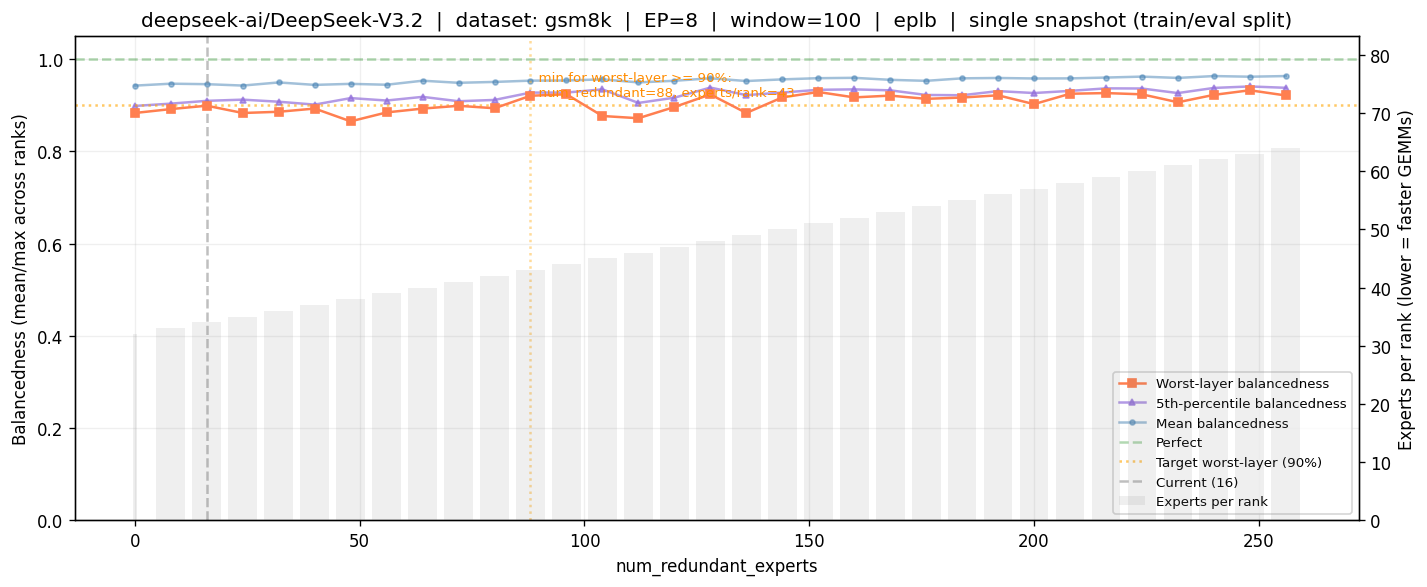

  Target   num_redundant   num_physical   experts/rank   worst_bal   mean_bal
------------------------------------------------------------------------------
     85%               0            256             32      0.8831     0.9425
     90%              88            344             43      0.9205     0.9532
     95%     not reached
     98%     not reached

Peak: num_redundant=248, worst_bal=0.9324, mean_bal=0.9618
Diminishing returns after num_redundant=16 (next step improves worst_bal by only -0.0158)


In [44]:
# Single-snapshot sweep: train on second-to-last, evaluate on last
n_snaps = len(d.data["snapshots"])
result = simulate_redundancy_sweep(
    d,
    train_snapshot_idx=n_snaps - 2,
    eval_snapshot_idx=n_snaps - 1,
)

plot_redundancy_sweep(
    result,
    title=f"{d.subtitle}  |  single snapshot (train/eval split)",
    target_balancedness=0.90,
    current_redundant=d.num_redundant,
)

print_sweep_summary(result)

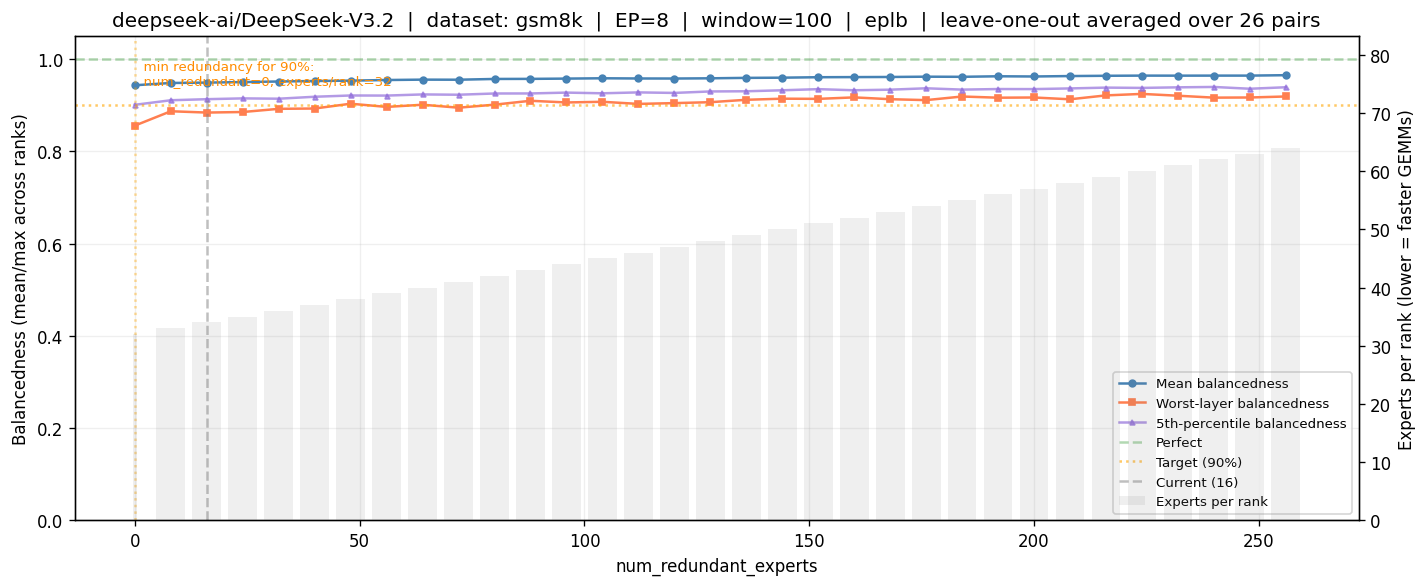

  Target   num_redundant   num_physical   experts/rank   mean_bal   worst_bal
------------------------------------------------------------------------------
     85%               0            256             32     0.9432      0.8558
     90%               0            256             32     0.9432      0.8558
     95%              24            280             35     0.9501      0.8852
     98%     not reached

Peak: num_redundant=256, mean_bal=0.9651, worst_bal=0.9189
Diminishing returns after num_redundant=0 (next step improves mean_bal by only +0.0049)


In [13]:
# Multi-snapshot sweep (leave-one-out: train on snapshot N-1, eval on N)
avg_result = sweep_across_snapshots(d, leave_one_out=True)

plot_redundancy_sweep(
    avg_result,
    title=f"{d.subtitle}  |  leave-one-out averaged over {len(d.data['snapshots']) - 1} pairs",
    target_balancedness=0.90,
    current_redundant=d.num_redundant,
)

print_sweep_summary(avg_result)

In [ ]:
# Compare multiple targets side-by-side
print_sweep_summary(avg_result, targets=[0.80, 0.85, 0.90, 0.92, 0.95, 0.98])

## Per-layer redundancy allocation

Instead of giving every layer the same `num_redundant_experts`, greedily
allocate a total budget of redundant expert slots to the layers that need
them most (the ones with the worst balancedness).  This shows how much
worst-layer balancedness could improve if the implementation supported
variable per-layer redundancy.

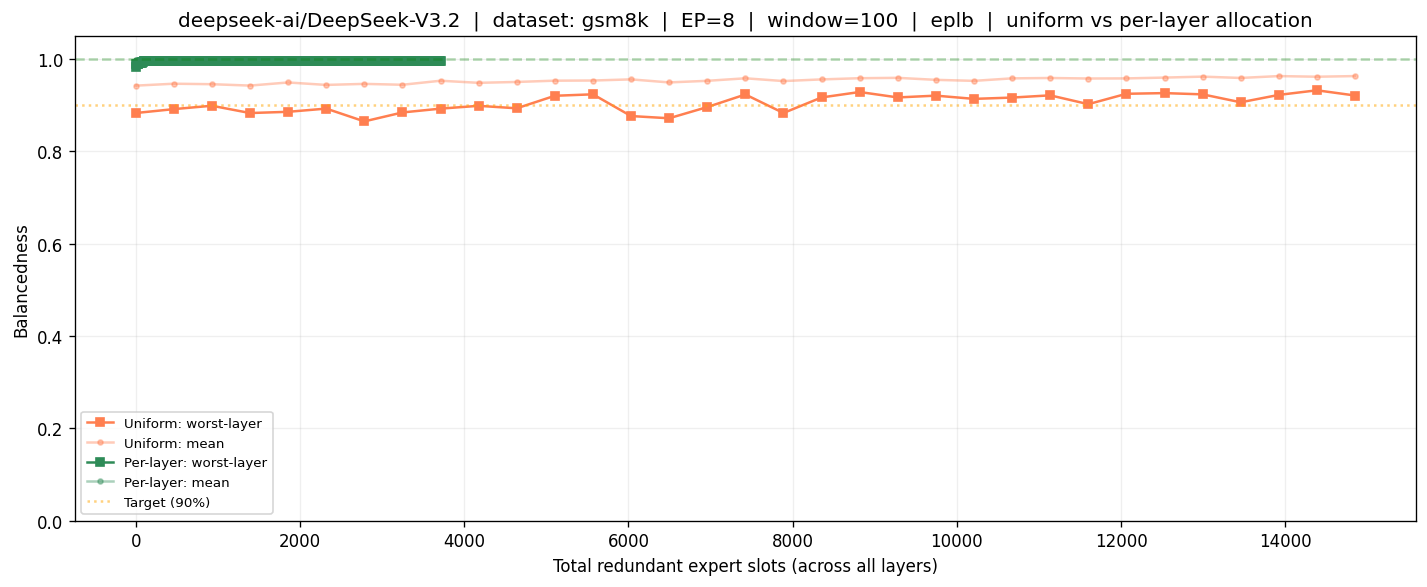

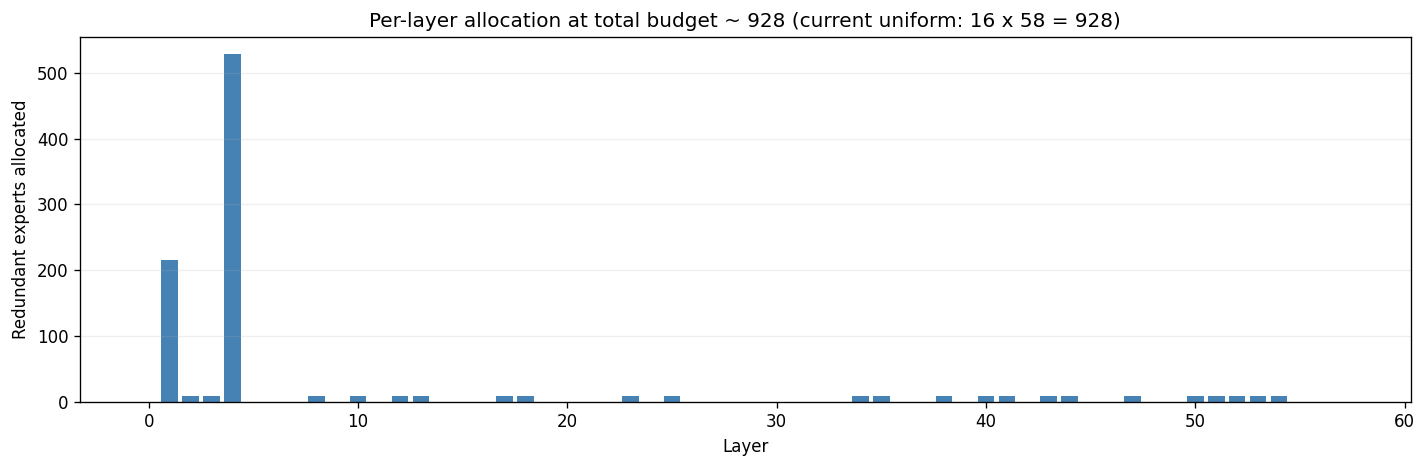

Total redundant: 928, layers with extra: 25/58


In [45]:
# Per-layer sweep: same total budget, smarter allocation
# Limit max total to the equivalent of 128 redundant per layer to keep it fast
max_total = d.num_redundant * d.num_layers * 4

n_snaps = len(d.data["snapshots"])
pl_result = simulate_per_layer_sweep(
    d,
    train_snapshot_idx=n_snaps - 2,
    eval_snapshot_idx=n_snaps - 1,
    max_total_redundant=max_total,
)

# Compare: uniform vs per-layer on the same total-budget x-axis
plot_uniform_vs_per_layer(
    result,
    pl_result,
    num_layers=d.num_layers,
    title=f"{d.subtitle}  |  uniform vs per-layer allocation",
)

# Where do the extra experts go?
# Pick the budget closest to the current uniform total
current_total = d.num_redundant * d.num_layers
closest_idx = int(np.argmin(np.abs(pl_result.total_redundant_values - current_total)))
plot_per_layer_allocation(
    pl_result,
    budget_idx=closest_idx,
    title=f"Per-layer allocation at total budget ~ {pl_result.total_redundant_values[closest_idx]}"
    f" (current uniform: {d.num_redundant} x {d.num_layers} = {current_total})",
)